# 🧠 Single Layer Perceptron Implementation

<div style="background-color:#1f2937;padding:15px;border-radius:10px">

<h3 style="color:#60a5fa;">📌 Topic</h3>
<p style="color:white;">
Implementation of a <b>Single Layer Perceptron</b> for binary classification using Python.
</p>

<h3 style="color:#34d399;">🎯 Objective</h3>
<p style="color:white;">
Understand the working of the perceptron algorithm and implement it from scratch to classify linearly separable data.
</p>

</div>

---

# 📚  Introduction to Perceptron

<div style="background-color:#f0f9ff;padding:15px;border-radius:10px">

The **Perceptron** is one of the **earliest neural network models**, introduced by **Frank Rosenblatt (1957)**.

It is a **supervised machine learning algorithm** used for **binary classification**.

### Key Idea
A perceptron learns a **linear decision boundary** to separate two classes.

### Mathematical Representation

\[
y = f(w_1x_1 + w_2x_2 + ... + w_nx_n + b)
\]

Where:

- **x** → input features  
- **w** → weights  
- **b** → bias  
- **f()** → activation function  
- **y** → predicted output  

</div>

---


# 📦 Importing Required Libraries

<div style="background-color:#eef2ff;padding:15px;border-radius:10px">

Before implementing the **Single Layer Perceptron**, we import several Python libraries that help with **data handling, visualization, model training, and evaluation**.

These libraries are widely used in **Machine Learning and Data Science workflows**.

</div>

---

Explanation

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from mlxtend.plotting import plot_decision_regions

<div style="background-color:#ecfeff;padding:15px;border-radius:10px">

In this step, we load the **Diabetes dataset** into our notebook so that it can be used for training and evaluating the **Single Layer Perceptron model**.

The dataset is stored as a **CSV (Comma-Separated Values) file**, which is a common format for structured data.

We use the **Pandas library** to read the dataset and convert it into a **DataFrame**, which allows easy data manipulation and analysis.

</div>


In [29]:
dataset = pd.read_csv('dataset/diabetes.csv')

In [30]:
dataset.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<div style="background-color:#f0fdf4;padding:15px;border-radius:10px">
We separate the dataset into **features (X)** using all columns except the last one with `dataset.iloc[:,:-1]`, and the **target variable (y)** as the `Outcome` column which the model will predict.x,y
</div>


In [31]:
x = dataset.iloc[:,:-1]
y = dataset['Outcome']

# 🚀 Model Training with Perceptron

<div style="background-color:#eef2ff;padding:15px;border-radius:10px">

In this step, we **split the dataset into training and testing sets** and then **train a Single Layer Perceptron model** using the training data.

</div>


In [35]:
x_train, x_test , y_train , y_test = train_test_split(x,y, test_size=0.10, random_state=22)

<div style="background-color:#fff7ed;padding:12px;border-radius:8px">

🔹 Here we initialize the Perceptron classifier, which is a single-layer neural network used for binary classification.

</div>

In [36]:
pr = Perceptron()

<div style="background-color:#ecfeff;padding:12px;border-radius:8px">

🔹 The fit() function trains the perceptron model using the training features (x_train) and training labels (y_train) so it can learn patterns in the data.

</div>

In [37]:
pr.fit(x_train,y_train)

Perceptron()

# 📊 Model Accuracy Evaluation

<div style="background-color:#f0f9ff;padding:15px;border-radius:10px">

After training the **Perceptron model**, we evaluate its performance by calculating the **accuracy on both training and testing datasets**.

</div>


In [38]:
pr.score(x_train,y_train)*100 , pr.score(x_test,y_test)*100

(66.13603473227207, 63.63636363636363)

# 📊 Data Visualization

<div style="background: linear-gradient(90deg,#6366f1,#06b6d4); padding:18px; border-radius:10px; color:white">

## 🔍 Understanding the Data Through Visualization

Data Visualization helps us **explore patterns, relationships, and distributions** within the dataset before training the machine learning model.

By representing the data graphically, we can easily identify:
- 📈 Trends in the dataset  
- 🔗 Relationships between features  
- ⚠️ Outliers or unusual values  
- 🧠 Important features that influence the prediction

</div>


In [39]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
dataset['combined_feature1'] = pca.fit_transform(dataset[['Pregnancies','Glucose','BloodPressure','SkinThickness']])
dataset['combined_feature2'] = pca.fit_transform(dataset[['Insulin','BMI','DiabetesPedigreeFunction','Age']])

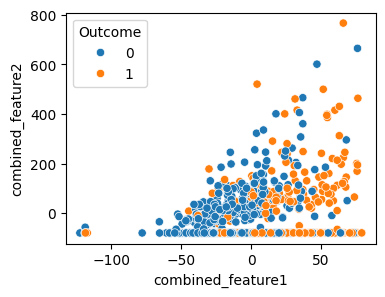

In [41]:
plt.figure(figsize=(4,3))
sns.scatterplot(x= dataset['combined_feature1'], y = dataset['combined_feature2'], hue = dataset['Outcome'])
plt.show()

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


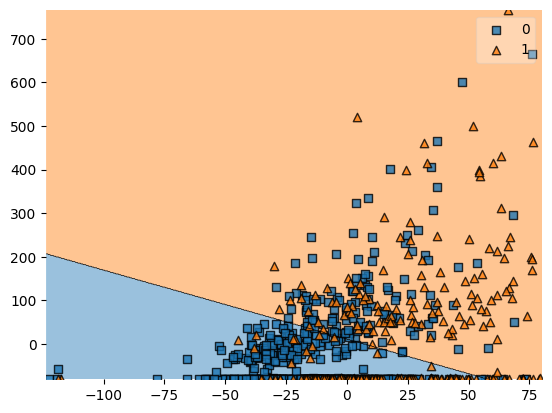

In [46]:
z = dataset[['combined_feature1','combined_feature2']]
pr.fit(z,y)
plot_decision_regions(z.to_numpy() ,y.to_numpy(), clf= pr)
plt.show()